In [39]:
from astropy.io import fits
from astropy.table import Table
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider

In [15]:
flat_hudl = fits.open('data/flat.fits')
flat_data = flat_hudl[0].data
print(flat_data.shape)

(4112, 385)


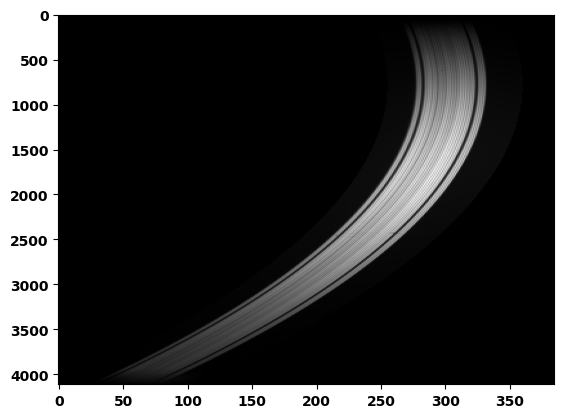

In [38]:
plt.imshow(flat_data,aspect = 'auto',cmap = 'grey')

In [44]:
%matplotlib widget

0

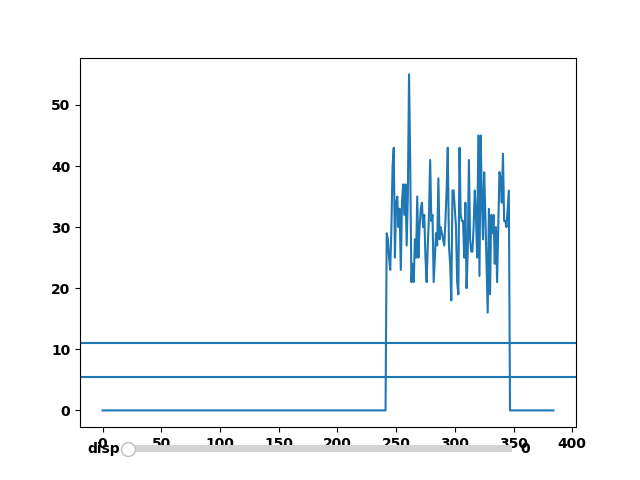

In [73]:
fig,ax = plt.subplots()
fctr_low = 0.1
fctr_high = 0.2
lines=[ax.plot(flat_data[0]),ax.axhline(y=fctr_low*max(flat_data[0])),ax.axhline(y=fctr_high*max(flat_data[0]))]
ax_slider = fig.add_axes([0.2, 0.05, 0.6, 0.03])
disp_slider = Slider(ax=ax_slider,valmin=0,valmax=len(flat_data[:,0])-1,valinit=0,label='disp')
def update(val):
    val=int(val)
    lines[0][0].set_ydata(flat_data[val])
    lines[1].set_ydata([fctr_low*max(flat_data[val]),fctr_low*max(flat_data[val])])
    lines[2].set_ydata([fctr_high*max(flat_data[val]),fctr_high*max(flat_data[val])])
    ax.relim()
    ax.autoscale_view()
    fig.canvas.draw_idle()

disp_slider.on_changed(update)

In [69]:
left_edges = []
right_edges = []
idxs = []
for i, row in enumerate(flat_data):
    threshold_low = 0.1*np.max(row)
    threshold_high = 0.2*np.max(row)
    tracks, = np.where((row<threshold_high) & (row>threshold_low))
    if len(tracks) != 2:
        continue
    left_edges.append(tracks[0])
    right_edges.append(tracks[1])
    idxs.append(i)

In [66]:
left_p = np.polyfit(idxs,left_edges,4)
right_p = np.polyfit(idxs,right_edges,4)

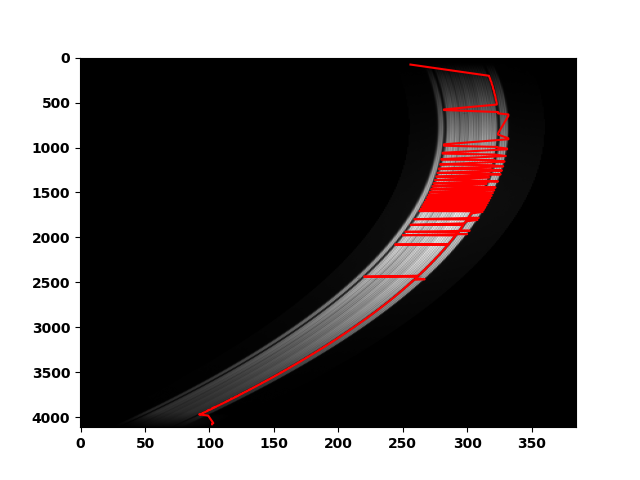

In [72]:
fig,ax = plt.subplots()
ax.imshow(flat_data,aspect='auto',cmap='grey')
# idxs = range(len(flat_data[:,0]))
#ax.plot(left_edges,idxs,c='r')
ax.plot(right_edges,idxs,c='r')